In [1]:
"""
Visualizing Loss Curves, Gradient Descent, and CNN Feature Maps
---------------------------------------------------------------

This notebook demonstrates:
- A simulated noisy loss curve typically seen in neural network training
- A 3D visualization of gradient descent navigating a loss landscape
- CNN feature map extraction from intermediate layers of a pre-trained VGG16 model
"""


'\nVisualizing Loss Curves, Gradient Descent, and CNN Feature Maps\n---------------------------------------------------------------\n\nThis notebook demonstrates:\n- A simulated noisy loss curve typically seen in neural network training\n- A 3D visualization of gradient descent navigating a loss landscape\n- CNN feature map extraction from intermediate layers of a pre-trained VGG16 model\n'

In [2]:

# Basic Libraries
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow and Keras
import tensorflow as tf


2025-04-26 07:45:16.011306: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-26 07:45:16.019156: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745678716.028440 1633791 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745678716.031231 1633791 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745678716.038973 1633791 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

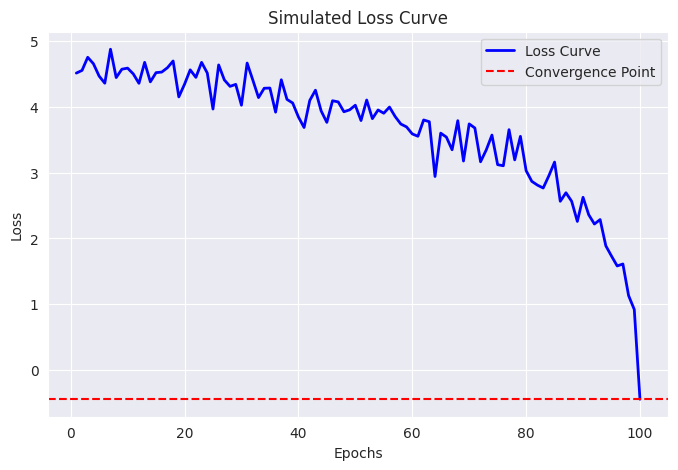

In [3]:

# Create a simulated loss curve
epochs = np.linspace(1, 100, 100)
loss_curve = np.log(epochs[::-1]) + np.random.normal(0, 0.2, size=len(epochs))

# Plot the loss curve
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_curve, label="Loss Curve", color="blue", linewidth=2)
plt.axhline(y=min(loss_curve), color="red", linestyle="--", label="Convergence Point")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Simulated Loss Curve")
plt.legend()
plt.show()


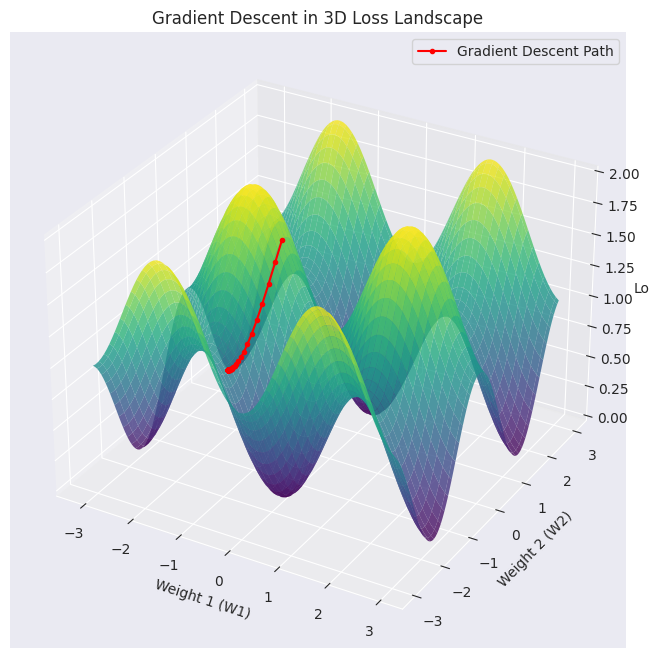

In [4]:

# Initialize random starting point
np.random.seed(42)
w1_path = [-2.5]
w2_path = [2.5]
learning_rate = 0.1

# Perform gradient descent steps
for _ in range(50):
    grad_w1 = 2 * np.sin(w1_path[-1]) * np.cos(w1_path[-1])
    grad_w2 = -2 * np.sin(w2_path[-1]) * np.cos(w2_path[-1])
    new_w1 = w1_path[-1] - learning_rate * grad_w1
    new_w2 = w2_path[-1] - learning_rate * grad_w2
    w1_path.append(new_w1)
    w2_path.append(new_w2)

# Create a 3D surface for visualization
W1, W2 = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
Loss = np.sin(W1)**2 + np.cos(W2)**2

# Convert paths to arrays
w1_path = np.array(w1_path)
w2_path = np.array(w2_path)
loss_path = np.sin(w1_path)**2 + np.cos(w2_path)**2

# Plot 3D loss surface and gradient descent path
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, Loss, cmap='viridis', edgecolor='none', alpha=0.8)
ax.plot(w1_path, w2_path, loss_path, color='red', marker='o', markersize=3, label="Gradient Descent Path")
ax.set_xlabel("Weight 1 (W1)")
ax.set_ylabel("Weight 2 (W2)")
ax.set_zlabel("Loss")
ax.set_title("Gradient Descent in 3D Loss Landscape")
ax.legend()
plt.show()


I0000 00:00:1745678717.749330 1633791 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 605 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1745678718.353012 1633955 service.cc:152] XLA service 0x7fb114005550 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745678718.353026 1633955 service.cc:160]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2025-04-26 07:45:18.357598: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745678718.382582 1633955 cuda_dnn.cc:529] Loaded cuDNN version 90800
2025-04-26 07:45:18.670648: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.06GiB with freed_by_count=0. The caller indicates that this is 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step


I0000 00:00:1745678718.925440 1633955 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


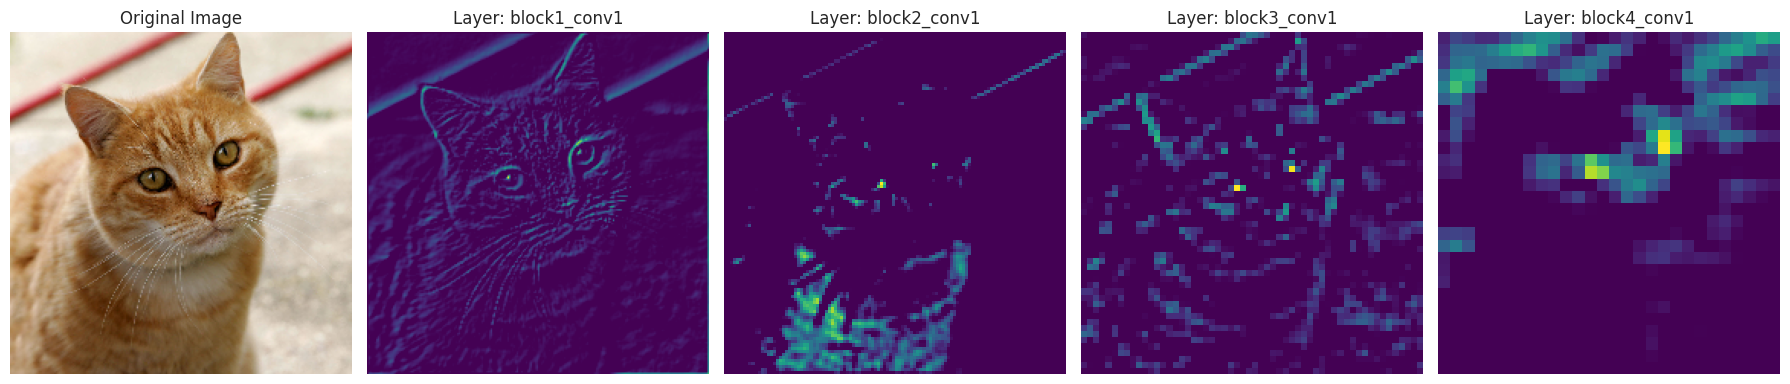

In [5]:

# Load pre-trained VGG16 model without top layers
model = tf.keras.applications.VGG16(weights="imagenet", include_top=False)

# Load and preprocess an example image
img_path = tf.keras.utils.get_file("cat.jpg", "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg")
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.vgg16.preprocess_input(img_array)

# Define layers to visualize
layer_names = ["block1_conv1", "block2_conv1", "block3_conv1", "block4_conv1"]
outputs = [model.get_layer(name).output for name in layer_names]
feature_extractor = tf.keras.Model(inputs=model.input, outputs=outputs)
feature_maps = feature_extractor.predict(img_array)

# Plot feature maps
fig, axes = plt.subplots(1, len(layer_names) + 1, figsize=(18, 5))

axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis("off")

for i, fmap in enumerate(feature_maps):
    axes[i+1].imshow(fmap[0, :, :, 0], cmap="viridis")
    axes[i+1].set_title(f"Layer: {layer_names[i]}")
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()
